# Feature Interactions Under Distribution Shift

## Research Question

When multiple features shift simultaneously, is the resulting
model-performance degradation simply the sum of their individual
effects, or do interactions between shifting features change the outcome?

## Dataset

UCI Bike Sharing Dataset — hourly bike rental data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
df = pd.read_csv("hour.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [3]:
print(df.columns)
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int

## Feature Exploration

We examine the main environmental and contextual features that may
influence bike rentals before selecting the model inputs.

In [4]:
# Check unique values of categorical features

print("Season:")
print(df["season"].value_counts())

print("\nWeather situation:")
print(df["weathersit"].value_counts())

print("\nWorking day:")
print(df["workingday"].value_counts())

Season:
season
3    4496
2    4409
1    4242
4    4232
Name: count, dtype: int64

Weather situation:
weathersit
1    11413
2     4544
3     1419
4        3
Name: count, dtype: int64

Working day:
workingday
1    11865
0     5514
Name: count, dtype: int64


In [5]:
print("Temperature statistics:")
print(df["temp"].describe())

print("\nHumidity statistics:")
print(df["hum"].describe())

print("\nWindspeed statistics:")
print(df["windspeed"].describe())

Temperature statistics:
count    17379.000000
mean         0.496987
std          0.192556
min          0.020000
25%          0.340000
50%          0.500000
75%          0.660000
max          1.000000
Name: temp, dtype: float64

Humidity statistics:
count    17379.000000
mean         0.627229
std          0.192930
min          0.000000
25%          0.480000
50%          0.630000
75%          0.780000
max          1.000000
Name: hum, dtype: float64

Windspeed statistics:
count    17379.000000
mean         0.190098
std          0.122340
min          0.000000
25%          0.104500
50%          0.194000
75%          0.253700
max          0.850700
Name: windspeed, dtype: float64


In [6]:
print("Correlation with bike rentals:")
print(df[["temp", "hum", "windspeed", "cnt"]].corr()["cnt"])

Correlation with bike rentals:
temp         0.404772
hum         -0.322911
windspeed    0.093234
cnt          1.000000
Name: cnt, dtype: float64


## Feature Selection

The target variable is `cnt`, representing total bike rentals.

We exclude `casual` and `registered` because they are components of
the target and would cause target leakage.

We also exclude `instant` and `dteday` from the initial model.

In [7]:
X = df[[
    "temp",
    "hum",
    "windspeed",
    "hr",
    "season",
    "workingday",
    "weathersit"
]]

y = df["cnt"]

print("Features:")
print(X.columns.tolist())

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['temp', 'hum', 'windspeed', 'hr', 'season', 'workingday', 'weathersit']

X shape: (17379, 7)
y shape: (17379,)


## Train-Test Split

We divide the dataset into training and testing sets.
The same split will be used for the distribution-shift experiments
so that the results can be compared fairly.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (13903, 7)
Testing data: (3476, 7)


## Baseline Linear Regression

We first train a Linear Regression model on the original training data.
This provides the baseline performance before introducing any shift.

In [9]:
model = LinearRegression()

model.fit(X_train, y_train)

baseline_predictions = model.predict(X_test)

In [10]:
baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_r2 = r2_score(y_test, baseline_predictions)

print("Baseline MAE:", baseline_mae)
print("Baseline R²:", baseline_r2)

Baseline MAE: 106.96115738373415
Baseline R²: 0.34290322116671157


## Distribution Shift

We simulate a change in the test distribution by shifting selected
features upward by a fixed amount.

The model is not retrained after the shift. This simulates a model
being evaluated on data whose feature distribution has changed.

In [11]:
def apply_shift(data, feature, amount):
    shifted_data = data.copy()
    shifted_data[feature] = (shifted_data[feature] + amount).clip(0, 1)
    return shifted_data

## Experiment 1: Temperature + Humidity

We test the individual effect of shifting temperature and humidity,
followed by their simultaneous shift.

In [12]:
# Temperature shift only
X_temp = apply_shift(X_test, "temp", 0.10)

# Humidity shift only
X_hum = apply_shift(X_test, "hum", 0.10)

# Temperature + humidity shift
X_temp_hum = X_test.copy()
X_temp_hum["temp"] = (X_temp_hum["temp"] + 0.10).clip(0, 1)
X_temp_hum["hum"] = (X_temp_hum["hum"] + 0.10).clip(0, 1)

# Predictions
temp_predictions = model.predict(X_temp)
hum_predictions = model.predict(X_hum)
temp_hum_predictions = model.predict(X_temp_hum)

# MAE
temp_mae = mean_absolute_error(y_test, temp_predictions)
hum_mae = mean_absolute_error(y_test, hum_predictions)
temp_hum_mae = mean_absolute_error(y_test, temp_hum_predictions)

print("Baseline MAE:", baseline_mae)
print("Temperature only MAE:", temp_mae)
print("Humidity only MAE:", hum_mae)
print("Temperature + Humidity MAE:", temp_hum_mae)

Baseline MAE: 106.96115738373415
Temperature only MAE: 116.49871349469778
Humidity only MAE: 103.18140645605304
Temperature + Humidity MAE: 108.93727577151502


In [13]:
# Individual effects
temp_effect = temp_mae - baseline_mae
hum_effect = hum_mae - baseline_mae

# Actual combined effect
temp_hum_effect = temp_hum_mae - baseline_mae

# Expected effect if the two effects were simply additive
expected_additive = temp_effect + hum_effect

# Interaction effect
interaction = temp_hum_effect - expected_additive

print("Temperature effect:", temp_effect)
print("Humidity effect:", hum_effect)
print("Combined effect:", temp_hum_effect)
print("Expected additive effect:", expected_additive)
print("Interaction:", interaction)

Temperature effect: 9.537556110963635
Humidity effect: -3.779750927681107
Combined effect: 1.976118387780872
Expected additive effect: 5.757805183282528
Interaction: -3.781686795501656


## Experiment 2: Temperature + Windspeed

We test whether the interaction observed for temperature and humidity
also occurs when temperature is shifted together with windspeed.

In [14]:
# Temperature shift only
X_temp = apply_shift(X_test, "temp", 0.10)

# Windspeed shift only
X_wind = apply_shift(X_test, "windspeed", 0.10)

# Temperature + windspeed shift
X_temp_wind = X_test.copy()
X_temp_wind["temp"] = (X_temp_wind["temp"] + 0.10).clip(0, 1)
X_temp_wind["windspeed"] = (X_temp_wind["windspeed"] + 0.10).clip(0, 1)

# Predictions
temp_predictions = model.predict(X_temp)
wind_predictions = model.predict(X_wind)
temp_wind_predictions = model.predict(X_temp_wind)

# MAE
temp_mae = mean_absolute_error(y_test, temp_predictions)
wind_mae = mean_absolute_error(y_test, wind_predictions)
temp_wind_mae = mean_absolute_error(y_test, temp_wind_predictions)

# Effects
temp_effect = temp_mae - baseline_mae
wind_effect = wind_mae - baseline_mae
temp_wind_effect = temp_wind_mae - baseline_mae

# Expected additive effect
expected_additive_wind = temp_effect + wind_effect

# Interaction
interaction_wind = temp_wind_effect - expected_additive_wind

print("Temperature effect:", temp_effect)
print("Windspeed effect:", wind_effect)
print("Combined effect:", temp_wind_effect)
print("Expected additive effect:", expected_additive_wind)
print("Interaction:", interaction_wind)

Temperature effect: 9.537556110963635
Windspeed effect: 0.311773315982407
Combined effect: 10.03880930338427
Expected additive effect: 9.849329426946042
Interaction: 0.18947987643822728


## Experiment 3: Humidity + Windspeed

We test whether the interaction between two shifted features
depends on which features are shifted simultaneously.

In [15]:
# Humidity shift only
X_hum = apply_shift(X_test, "hum", 0.10)

# Windspeed shift only
X_wind = apply_shift(X_test, "windspeed", 0.10)

# Humidity + windspeed shift
X_hum_wind = X_test.copy()
X_hum_wind["hum"] = (X_hum_wind["hum"] + 0.10).clip(0, 1)
X_hum_wind["windspeed"] = (X_hum_wind["windspeed"] + 0.10).clip(0, 1)

# Predictions
hum_predictions = model.predict(X_hum)
wind_predictions = model.predict(X_wind)
hum_wind_predictions = model.predict(X_hum_wind)

# MAE
hum_mae = mean_absolute_error(y_test, hum_predictions)
wind_mae = mean_absolute_error(y_test, wind_predictions)
hum_wind_mae = mean_absolute_error(y_test, hum_wind_predictions)

# Effects
hum_effect = hum_mae - baseline_mae
wind_effect = wind_mae - baseline_mae
hum_wind_effect = hum_wind_mae - baseline_mae

# Expected additive effect
expected_additive_hum_wind = hum_effect + wind_effect

# Interaction
interaction_hum_wind = hum_wind_effect - expected_additive_hum_wind

print("Humidity effect:", hum_effect)
print("Windspeed effect:", wind_effect)
print("Combined effect:", hum_wind_effect)
print("Expected additive effect:", expected_additive_hum_wind)
print("Interaction:", interaction_hum_wind)

Humidity effect: -3.779750927681107
Windspeed effect: 0.311773315982407
Combined effect: -3.646679492160416
Expected additive effect: -3.4679776116987
Interaction: -0.1787018804617162


In [16]:
results = pd.DataFrame({
    "Feature Pair": [
        "Temperature + Humidity",
        "Temperature + Windspeed",
        "Humidity + Windspeed"
    ],
    "Interaction": [
        interaction,
        interaction_wind,
        interaction_hum_wind
    ]
})

results

,Feature Pair,Interaction
0,Temperature + Humidity,-3.781687
1,Temperature + Windspeed,0.189480
2,Humidity + Windspeed,-0.178702


## Robustness Check: Random Forest

We repeat the main experiment using a Random Forest Regressor.
This helps determine whether the observed interaction pattern
depends only on the Linear Regression model.

In [17]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_baseline_predictions = rf_model.predict(X_test)

rf_baseline_mae = mean_absolute_error(
    y_test,
    rf_baseline_predictions
)

print("Random Forest baseline MAE:", rf_baseline_mae)

Random Forest baseline MAE: 46.90149061592416


## Random Forest Experiment: Temperature + Humidity

In [18]:
# Temperature shift only
rf_X_temp = apply_shift(X_test, "temp", 0.10)

# Humidity shift only
rf_X_hum = apply_shift(X_test, "hum", 0.10)

# Temperature + humidity shift
rf_X_temp_hum = X_test.copy()
rf_X_temp_hum["temp"] = (rf_X_temp_hum["temp"] + 0.10).clip(0, 1)
rf_X_temp_hum["hum"] = (rf_X_temp_hum["hum"] + 0.10).clip(0, 1)

# Predictions
rf_temp_predictions = rf_model.predict(rf_X_temp)
rf_hum_predictions = rf_model.predict(rf_X_hum)
rf_temp_hum_predictions = rf_model.predict(rf_X_temp_hum)

# MAE
rf_temp_mae = mean_absolute_error(y_test, rf_temp_predictions)
rf_hum_mae = mean_absolute_error(y_test, rf_hum_predictions)
rf_temp_hum_mae = mean_absolute_error(y_test, rf_temp_hum_predictions)

# Effects
rf_temp_effect = rf_temp_mae - rf_baseline_mae
rf_hum_effect = rf_hum_mae - rf_baseline_mae
rf_temp_hum_effect = rf_temp_hum_mae - rf_baseline_mae

# Expected additive effect
rf_expected_additive = rf_temp_effect + rf_hum_effect

# Interaction
rf_interaction = rf_temp_hum_effect - rf_expected_additive

print("Temperature effect:", rf_temp_effect)
print("Humidity effect:", rf_hum_effect)
print("Combined effect:", rf_temp_hum_effect)
print("Expected additive effect:", rf_expected_additive)
print("Interaction:", rf_interaction)

Temperature effect: 10.282169683955289
Humidity effect: 1.856460564049172
Combined effect: 10.319662998657456
Expected additive effect: 12.13863024800446
Interaction: -1.8189672493470042


## Model Robustness: Temperature + Humidity

We compare the temperature + humidity interaction obtained from
Linear Regression and Random Forest.

In [19]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "Interaction": [
        interaction,
        rf_interaction
    ]
})

model_comparison

,Model,Interaction
0,Linear Regression,-3.781687
1,Random Forest,-1.818967


## Robustness Check: Different Train/Test Splits

We repeat the experiment using different random seeds to check
whether the observed interaction depends strongly on one particular split.

In [20]:
seeds = [42, 21, 7]
seed_results = []

for seed in seeds:

    # New train/test split
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=seed
    )

    # Train Linear Regression
    seed_model = LinearRegression()
    seed_model.fit(X_train_s, y_train_s)

    # Baseline
    baseline_pred_s = seed_model.predict(X_test_s)
    baseline_mae_s = mean_absolute_error(y_test_s, baseline_pred_s)

    # Temperature shift
    temp_s = apply_shift(X_test_s, "temp", 0.10)

    # Humidity shift
    hum_s = apply_shift(X_test_s, "hum", 0.10)

    # Both shifts
    both_s = X_test_s.copy()
    both_s["temp"] = (both_s["temp"] + 0.10).clip(0, 1)
    both_s["hum"] = (both_s["hum"] + 0.10).clip(0, 1)

    # Predictions
    temp_pred_s = seed_model.predict(temp_s)
    hum_pred_s = seed_model.predict(hum_s)
    both_pred_s = seed_model.predict(both_s)

    # MAE
    temp_mae_s = mean_absolute_error(y_test_s, temp_pred_s)
    hum_mae_s = mean_absolute_error(y_test_s, hum_pred_s)
    both_mae_s = mean_absolute_error(y_test_s, both_pred_s)

    # Effects
    temp_effect_s = temp_mae_s - baseline_mae_s
    hum_effect_s = hum_mae_s - baseline_mae_s
    both_effect_s = both_mae_s - baseline_mae_s

    # Interaction
    expected_s = temp_effect_s + hum_effect_s
    interaction_s = both_effect_s - expected_s

    seed_results.append({
        "Seed": seed,
        "Baseline MAE": baseline_mae_s,
        "Interaction": interaction_s
    })

seed_results_df = pd.DataFrame(seed_results)

seed_results_df

,Seed,Baseline MAE,Interaction
0,42,106.961157,-3.781687
1,21,109.177192,-3.870175
2,7,109.413971,-4.050587


## Sensitivity Check: Boundary-Safe Shift

The original shift adds a fixed amount and clips values at 1.
As a sensitivity check, we instead move each value 10% toward
the upper boundary without clipping.

In [21]:
# Boundary-safe temperature shift
X_safe_temp = X_test.copy()
X_safe_temp["temp"] = X_safe_temp["temp"] + 0.10 * (1 - X_safe_temp["temp"])

# Boundary-safe humidity shift
X_safe_hum = X_test.copy()
X_safe_hum["hum"] = X_safe_hum["hum"] + 0.10 * (1 - X_safe_hum["hum"])

# Boundary-safe temperature + humidity shift
X_safe_both = X_test.copy()
X_safe_both["temp"] = X_safe_both["temp"] + 0.10 * (1 - X_safe_both["temp"])
X_safe_both["hum"] = X_safe_both["hum"] + 0.10 * (1 - X_safe_both["hum"])

# Predictions
safe_temp_pred = model.predict(X_safe_temp)
safe_hum_pred = model.predict(X_safe_hum)
safe_both_pred = model.predict(X_safe_both)

# MAE
safe_temp_mae = mean_absolute_error(y_test, safe_temp_pred)
safe_hum_mae = mean_absolute_error(y_test, safe_hum_pred)
safe_both_mae = mean_absolute_error(y_test, safe_both_pred)

# Effects
safe_temp_effect = safe_temp_mae - baseline_mae
safe_hum_effect = safe_hum_mae - baseline_mae
safe_both_effect = safe_both_mae - baseline_mae

# Expected additive effect
safe_expected = safe_temp_effect + safe_hum_effect

# Interaction
safe_interaction = safe_both_effect - safe_expected

print("Baseline MAE:", baseline_mae)
print("Temperature only MAE:", safe_temp_mae)
print("Humidity only MAE:", safe_hum_mae)
print("Both MAE:", safe_both_mae)

print("\nTemperature effect:", safe_temp_effect)
print("Humidity effect:", safe_hum_effect)
print("Combined effect:", safe_both_effect)
print("Expected additive effect:", safe_expected)
print("Interaction:", safe_interaction)

Baseline MAE: 106.96115738373415
Temperature only MAE: 111.36849104005445
Humidity only MAE: 105.16938600673713
Both MAE: 108.74896569243627

Temperature effect: 4.407333656320304
Humidity effect: -1.7917713769970192
Combined effect: 1.7878083087021253
Expected additive effect: 2.615562279323285
Interaction: -0.8277539706211599


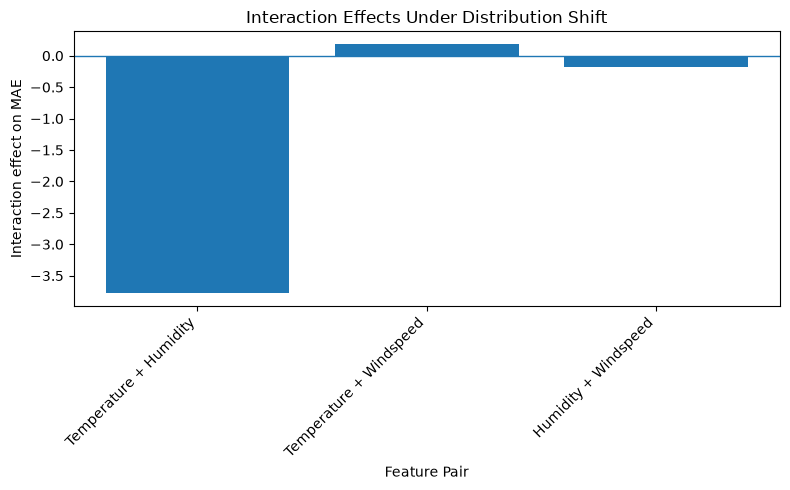

In [22]:
plt.figure(figsize=(8, 5))

plt.bar(
    results["Feature Pair"],
    results["Interaction"]
)

plt.axhline(0, linewidth=1)

plt.ylabel("Interaction effect on MAE")
plt.xlabel("Feature Pair")
plt.title("Interaction Effects Under Distribution Shift")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Sensitivity of Temperature + Humidity Interaction

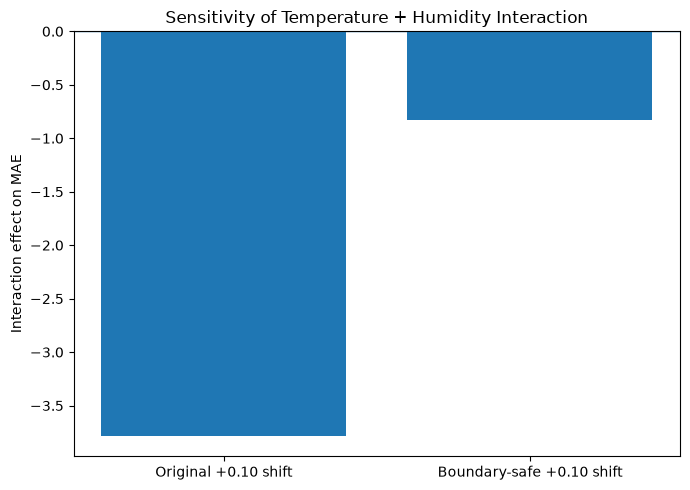

In [23]:
plt.figure(figsize=(7, 5))

labels = [
    "Original +0.10 shift",
    "Boundary-safe +0.10 shift"
]

values = [
    interaction,
    safe_interaction
]

plt.bar(labels, values)

plt.axhline(0, linewidth=1)

plt.ylabel("Interaction effect on MAE")
plt.title("Sensitivity of Temperature + Humidity Interaction")

plt.tight_layout()
plt.show()

## Robustness Across Train/Test Splits

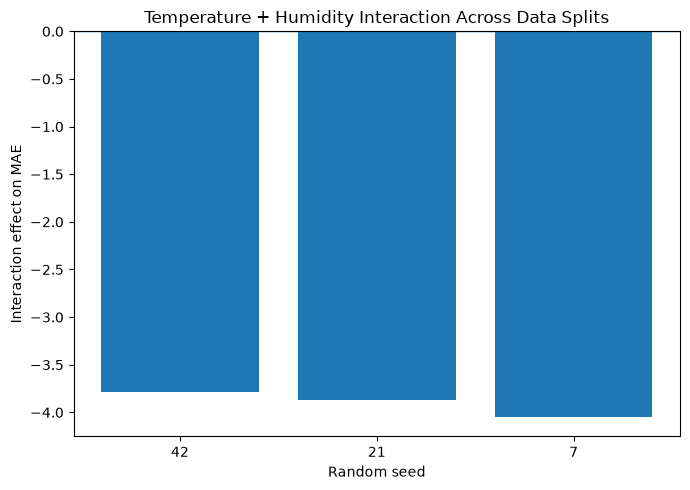

In [24]:
plt.figure(figsize=(7, 5))

plt.bar(
    seed_results_df["Seed"].astype(str),
    seed_results_df["Interaction"]
)

plt.axhline(0, linewidth=1)

plt.xlabel("Random seed")
plt.ylabel("Interaction effect on MAE")
plt.title("Temperature + Humidity Interaction Across Data Splits")

plt.tight_layout()
plt.show()

# Preliminary Findings

The experiments indicate that the effect of simultaneous feature shifts
is not always equal to the sum of the individual effects.

For the UCI Bike Sharing dataset, the temperature + humidity pair showed
a negative interaction under both Linear Regression and Random Forest.
The interaction also remained negative across different train/test splits.

In contrast, temperature + windspeed and humidity + windspeed produced
interactions close to zero under the tested setup.

A boundary-safe shift produced the same negative direction for temperature
+ humidity, although the magnitude was smaller. This indicates that the
observed interaction is sensitive to the definition of distribution shift.

These findings are exploratory and should not be interpreted as evidence
that temperature and humidity always interact in the same way across
datasets or models.

# Limitations

- The study uses one dataset.
- Only three environmental feature pairs were examined.
- The primary experiments used a +0.10 shift, with an alternative boundary-safe shift used as a sensitivity check.
- The distribution shifts are artificially constructed.
- The original shift uses clipping at the upper boundary.
- The magnitude of the interaction depends on the shift definition.
- Only Linear Regression and Random Forest were evaluated.
- The results are exploratory and may not generalize to other datasets.

# Results

## 1. Linear Regression: Feature-Pair Interactions

The interaction effects were calculated for three environmental feature
pairs under a +0.10 distribution shift. The interaction value indicates
whether the combined effect differs from the sum of the individual effects.

In [25]:
results

,Feature Pair,Interaction
0,Temperature + Humidity,-3.781687
1,Temperature + Windspeed,0.189480
2,Humidity + Windspeed,-0.178702


The temperature + humidity pair showed the largest negative interaction,
while temperature + windspeed and humidity + windspeed produced interaction
values close to zero.

This suggests that, under the tested experimental setup, the combined
shift in temperature and humidity produced less performance degradation
than would be expected from simply adding their individual effects.

## 2. Model Robustness

The temperature + humidity experiment was repeated using a Random Forest
Regressor. Both Linear Regression and Random Forest produced a negative
interaction, although the magnitude differed between the models.

In [26]:
model_comparison

,Model,Interaction
0,Linear Regression,-3.781687
1,Random Forest,-1.818967


## 3. Train/Test Split Robustness

The temperature + humidity experiment was repeated using three different
random seeds. The interaction remained negative across all three splits.

In [27]:
seed_results_df

,Seed,Baseline MAE,Interaction
0,42,106.961157,-3.781687
1,21,109.177192,-3.870175
2,7,109.413971,-4.050587


## 4. Shift-Definition Sensitivity

A boundary-safe shift was used as an alternative to the original
fixed-addition-and-clipping method. The temperature + humidity interaction
remained negative, although its magnitude changed.

# Discussion

The results show that simultaneous shifts in multiple features do not
always produce a performance change equal to the sum of their individual
effects.

The temperature + humidity pair consistently produced a negative
interaction under the tested conditions. This pattern was observed with
both Linear Regression and Random Forest and remained negative across
different train/test splits.

In comparison, temperature + windspeed and humidity + windspeed produced
interaction values close to zero, suggesting approximately additive
effects under the same experimental setup.

The boundary-safe sensitivity experiment also produced a negative
temperature + humidity interaction, although its magnitude was smaller.
This indicates that the observed interaction depends partly on how the
distribution shift is defined.

Therefore, the results provide evidence that the effect of simultaneous
feature shifts can depend on the combination of features and the
experimental setup, rather than always being purely additive.

# Conclusion

This study investigated whether simultaneous shifts in multiple features
produce model-performance degradation that is simply additive or whether
interactions between shifting features can change the outcome.

For the UCI Bike Sharing dataset, temperature + humidity showed a
consistently negative interaction under the tested conditions. In contrast,
temperature + windspeed and humidity + windspeed produced interactions
close to zero.

The temperature + humidity interaction remained negative across different
models, train/test splits, and an alternative shift definition. However,
its magnitude changed across these conditions.

Therefore, within the scope of this exploratory study, simultaneous
feature shifts do not always behave as a simple sum of their individual
effects. The results suggest that the relationship between multiple
shifting features and model performance can depend on the feature
combination, model, and definition of distribution shift.

Further experiments using additional datasets, models, feature pairs, and
real-world distribution shifts would be needed to determine how broadly
these findings apply.

# Future Work

Future studies could extend this work by:

- Testing additional datasets from different application domains.
- Examining more feature pairs and larger numbers of simultaneously
  shifting features.
- Testing a wider range of shift magnitudes.
- Evaluating additional machine-learning models.
- Using real-world temporal or domain-based distribution shifts instead of
  only artificially constructed shifts.
- Investigating whether similar interaction patterns occur under other
  performance metrics besides MAE.

# References

1. UCI Machine Learning Repository. Bike Sharing Dataset.
   https://archive.ics.uci.edu/dataset/275/bike%2Bsharing%2Bdataset

2. Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in
   Python. Journal of Machine Learning Research, 12, 2825–2830.

3. McKinney, W. (2010). Data Structures for Statistical Computing in
   Python. Proceedings of the 9th Python in Science Conference.